In [2]:
pip install sentence_transformers


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
#https://huggingface.co/sentence-transformers

In [4]:
#import sentence transformer and cosine similarity 
#pip install -U sentence-transformers - if not installed
#import pandas for data manipulation tasks and 
# matplotlib for pictorial representation of similarity score in histogram 

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Build SentenceTransformer model consider code snippet from hugging face sentence transformer
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2886.69it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
# Reading csv file 
df = pd.read_csv("Doc_Revisions.csv")

# Generate embeddings of original and revised and converting to list 
embeddings_orig = model.encode(df['original_text'].tolist())
embeddings_rev = model.encode(df['revised_text'].tolist())

In [7]:
# Compute similarity score for both original and revised embedding
scores = []
for i in range(len(df)):
    sim = cosine_similarity([embeddings_orig[i]], [embeddings_rev[i]])[0][0]
    scores.append(sim)

In [8]:
# Classification of these original and revised embeddings based threshold 
threshold = 0.75

df['similarity'] = scores
# Create a new column lable which save data as High Similarity or Low Similarity based on the threshold provided
df['label'] = df['similarity'].apply(lambda x: "High Similarity" if x >= threshold else "Low Similarity")

# Now display the results we generated to the console using dataframe.head() will give 5 datapoints
print(df.head())

   doc_pair_id                                      original_text  \
0            1  All employees must complete security training ...   
1            2  Data backups should be stored offsite to preve...   
2            3   Users must change their passwords every 90 days.   
3            4  Incidents must be reported to the IT helpdesk ...   
4            5  Access to confidential data requires manager a...   

                                        revised_text  Unnamed: 3  Unnamed: 4  \
0  Employees are required to undergo yearly secur...         NaN         NaN   
1  Store backups at an offsite location to avoid ...         NaN         NaN   
2  Passwords must be updated by users at least on...         NaN         NaN   
3  Report any security incidents to IT support wi...         NaN         NaN   
4  Manager approval is required for confidential ...         NaN         NaN   

   Unnamed: 5  Unnamed: 6  similarity            label  
0         NaN         NaN    0.857968  High Sim

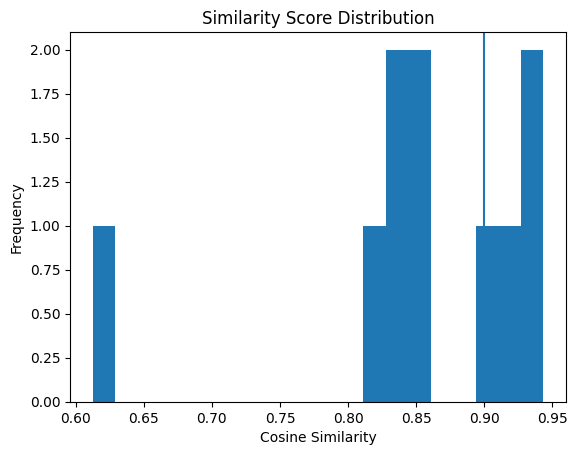

In [11]:
# Histogram 
plt.figure()
plt.hist(df['similarity'], bins=20)
plt.axvline(threshold)  # threshold line
plt.title("Similarity Score Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.show()

   doc_pair_id                                      original_text  \
0            1  All employees must complete security training ...   
1            2  Data backups should be stored offsite to preve...   
2            3   Users must change their passwords every 90 days.   
3            4  Incidents must be reported to the IT helpdesk ...   
4            5  Access to confidential data requires manager a...   

                                        revised_text  Unnamed: 3  Unnamed: 4  \
0  Employees are required to undergo yearly secur...         NaN         NaN   
1  Store backups at an offsite location to avoid ...         NaN         NaN   
2  Passwords must be updated by users at least on...         NaN         NaN   
3  Report any security incidents to IT support wi...         NaN         NaN   
4  Manager approval is required for confidential ...         NaN         NaN   

   Unnamed: 5  Unnamed: 6  similarity            label  
0         NaN         NaN    0.857968   Low Sim

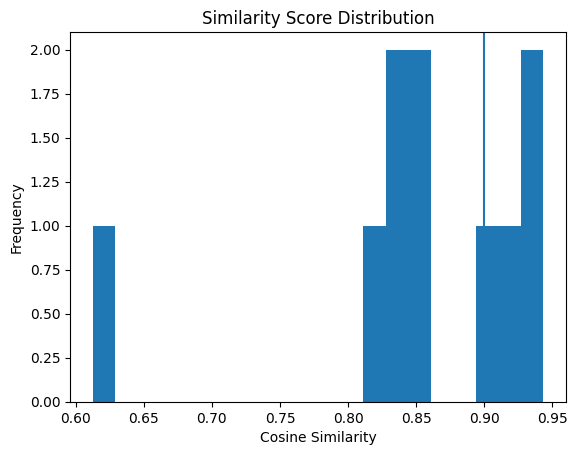

In [10]:
threshold = 0.9
df['label'] = df['similarity'].apply(lambda x: "High Similarity" if x >= threshold else "Low Similarity")

print(df.head())

# Histogram
plt.figure()
plt.hist(df['similarity'], bins=20)
plt.axvline(threshold)
plt.title("Similarity Score Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.show()